In [1]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import os
import seaborn as sns
from pathlib import Path

# ── IEEE publication style ────────────────────────────────────────────────
matplotlib.rcParams.update({
    'font.family':       'serif',
    'font.size':         9,
    'axes.titlesize':    10,
    'axes.labelsize':    9,
    'xtick.labelsize':   8,
    'ytick.labelsize':   8,
    'legend.fontsize':   8,
    'figure.dpi':        300,
    'savefig.dpi':       300,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         False,
})

FIG_DIR  = Path('../figures')
CSV_DIR  = Path('../results/csvs')
os.makedirs(FIG_DIR, exist_ok=True)

DPI        = 300
W_SINGLE   = 3.5   # inches — IEEE single column
W_DOUBLE   = 7.0   # inches — IEEE double column

# Colour palette (colour-blind friendly)
C_BASE  = '#1f77b4'   # blue  — baseline
C_MS    = '#ff7f0e'   # orange — match-sensitive
C_THEO  = '#999999'   # gray   — theoretical reference
C_PEAK  = '#d62728'   # red    — peak marker
C_INC   = '#2ca02c'   # green  — increasing arrow
C_DEC   = '#9467bd'   # purple — decreasing arrow

print('Matplotlib version:', matplotlib.__version__)
print('Output directory  :', FIG_DIR.resolve())
print('Style configured  : serif, 9pt, 300 DPI, IEEE column widths')

Matplotlib version: 3.10.9
Output directory  : E:\Bioinformatics Project AIUB\Main Code\figures
Style configured  : serif, 9pt, 300 DPI, IEEE column widths


## Figure 1: Match Point Visualization (reproducing paper Fig. 1)

Recreates the match-point grid from Section 1 of the paper, showing how the LCBS path traverses increasing then decreasing matches.

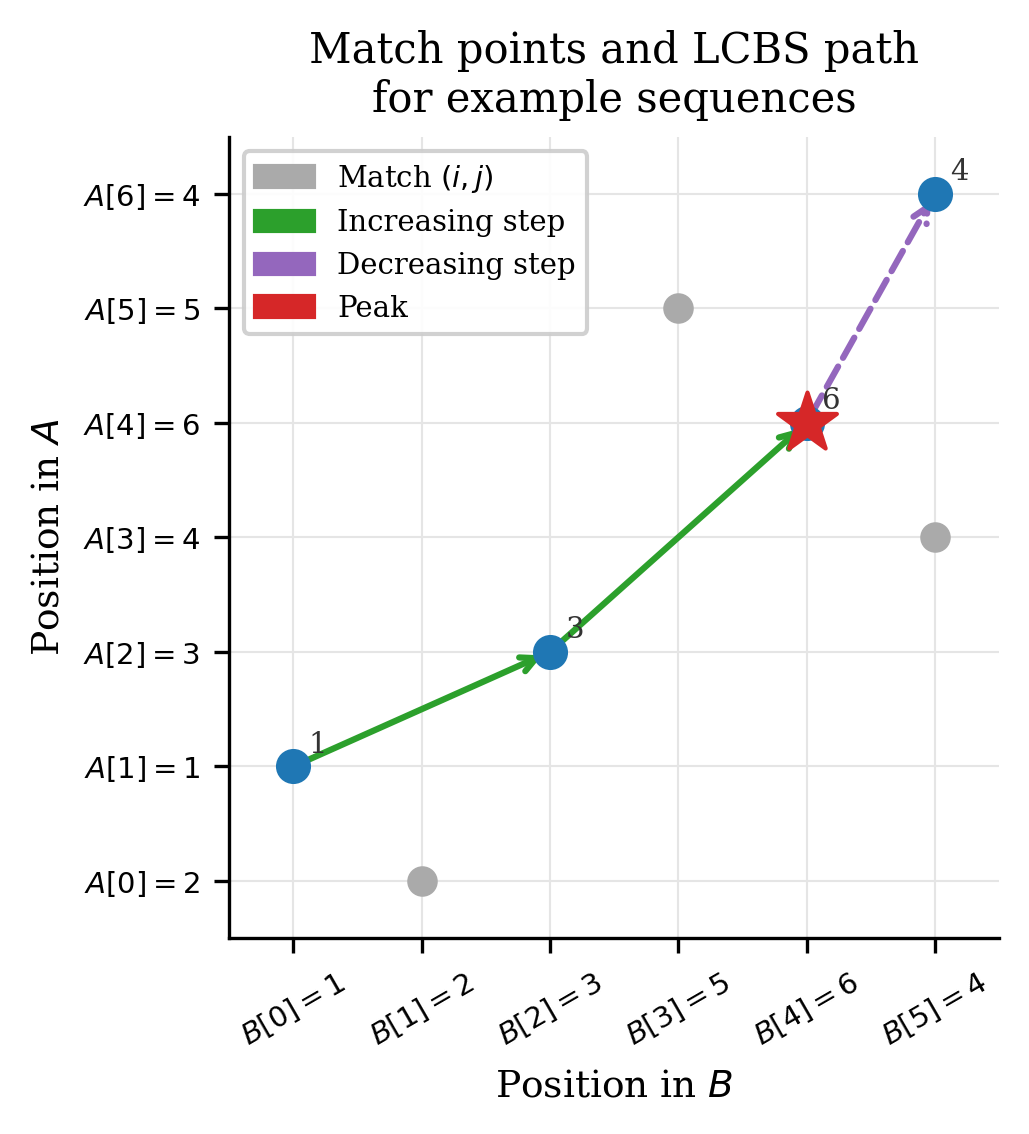

Saved: ..\figures\fig1_match_points.png  (89 KB)


In [2]:
A = [2, 1, 3, 4, 6, 5, 4]
B = [1, 2, 3, 5, 6, 4]

# All match points: (i, j) where A[i] == B[j]
matches = [(i, j) for i in range(len(A)) for j in range(len(B)) if A[i] == B[j]]

# LCBS path: [1→3→6→4] with peak at 6
# match coords: (i, j) tuples
lcbs_path  = [(1,0), (2,2), (4,4), (6,5)]   # values: 1,3,6,4  peak=(4,4)
peak_match = (4, 4)
inc_path   = [(1,0), (2,2), (4,4)]           # increasing: 1→3→6
dec_path   = [(4,4), (6,5)]                  # decreasing: 6→4

fig, ax = plt.subplots(figsize=(W_SINGLE, W_SINGLE * 1.1))

# Grid lines (light)
for i in range(len(A)):
    ax.axhline(i, color='#e5e5e5', linewidth=0.5, zorder=0)
for j in range(len(B)):
    ax.axvline(j, color='#e5e5e5', linewidth=0.5, zorder=0)

# All match points (gray)
non_path = [m for m in matches if m not in lcbs_path]
if non_path:
    xi, yi = zip(*[(j, i) for (i,j) in non_path])
    ax.scatter(xi, yi, color='#aaaaaa', s=40, zorder=3,
               label='Match $(i,j)$', marker='o')

# LCBS path matches (coloured)
path_x = [j for (i,j) in lcbs_path]
path_y = [i for (i,j) in lcbs_path]
ax.scatter(path_x, path_y, color=C_BASE, s=55, zorder=5, marker='o')

# Increasing arrows (solid green)
arrowprops_inc = dict(arrowstyle='->', color=C_INC, lw=1.5)
for k in range(len(inc_path)-1):
    (i0,j0), (i1,j1) = inc_path[k], inc_path[k+1]
    ax.annotate('', xy=(j1, i1), xytext=(j0, i0),
                arrowprops=arrowprops_inc)

# Decreasing arrow (dashed purple)
arrowprops_dec = dict(arrowstyle='->', color=C_DEC, lw=1.5,
                      linestyle='dashed',
                      connectionstyle='arc3,rad=0.0')
for k in range(len(dec_path)-1):
    (i0,j0), (i1,j1) = dec_path[k], dec_path[k+1]
    ax.annotate('', xy=(j1, i1), xytext=(j0, i0),
                arrowprops=arrowprops_dec)

# Peak star
pi, pj = peak_match
ax.scatter([pj], [pi], marker='*', s=220, color=C_PEAK, zorder=6,
           label=f'Peak  $A[{pi}]=B[{pj}]={A[pi]}$')

# Value labels on match points
for (i, j) in lcbs_path:
    ax.text(j + 0.12, i + 0.12, str(A[i]), fontsize=7, color='#333333', zorder=7)

# Axis ticks and labels
ax.set_xticks(range(len(B)))
ax.set_xticklabels([f'$B[{j}]={B[j]}$' for j in range(len(B))], fontsize=7, rotation=30)
ax.set_yticks(range(len(A)))
ax.set_yticklabels([f'$A[{i}]={A[i]}$' for i in range(len(A))], fontsize=7)
ax.set_xlim(-0.5, len(B) - 0.5)
ax.set_ylim(-0.5, len(A) - 0.5)
ax.set_xlabel('Position in $B$')
ax.set_ylabel('Position in $A$')
ax.set_title('Match points and LCBS path\nfor example sequences')

# Legend handles (manual, for arrows)
h_match = mpatches.Patch(color='#aaaaaa', label='Match $(i,j)$')
h_inc   = mpatches.Patch(color=C_INC,    label='Increasing step')
h_dec   = mpatches.Patch(color=C_DEC,    label='Decreasing step')
h_peak  = mpatches.Patch(color=C_PEAK,   label='Peak')
ax.legend(handles=[h_match, h_inc, h_dec, h_peak],
          loc='upper left', framealpha=0.9, fontsize=7)

plt.tight_layout()
out1 = FIG_DIR / 'fig1_match_points.png'
plt.savefig(out1, dpi=DPI, bbox_inches='tight')
plt.show()
print(f'Saved: {out1}  ({os.path.getsize(out1)//1024} KB)')

## Figure 2: Runtime Benchmark (Theorem 3 & 5 Validation)

2×2 log-log runtime plot for all four alphabet sizes, comparing the two algorithms against a theoretical Θ(n²) reference.

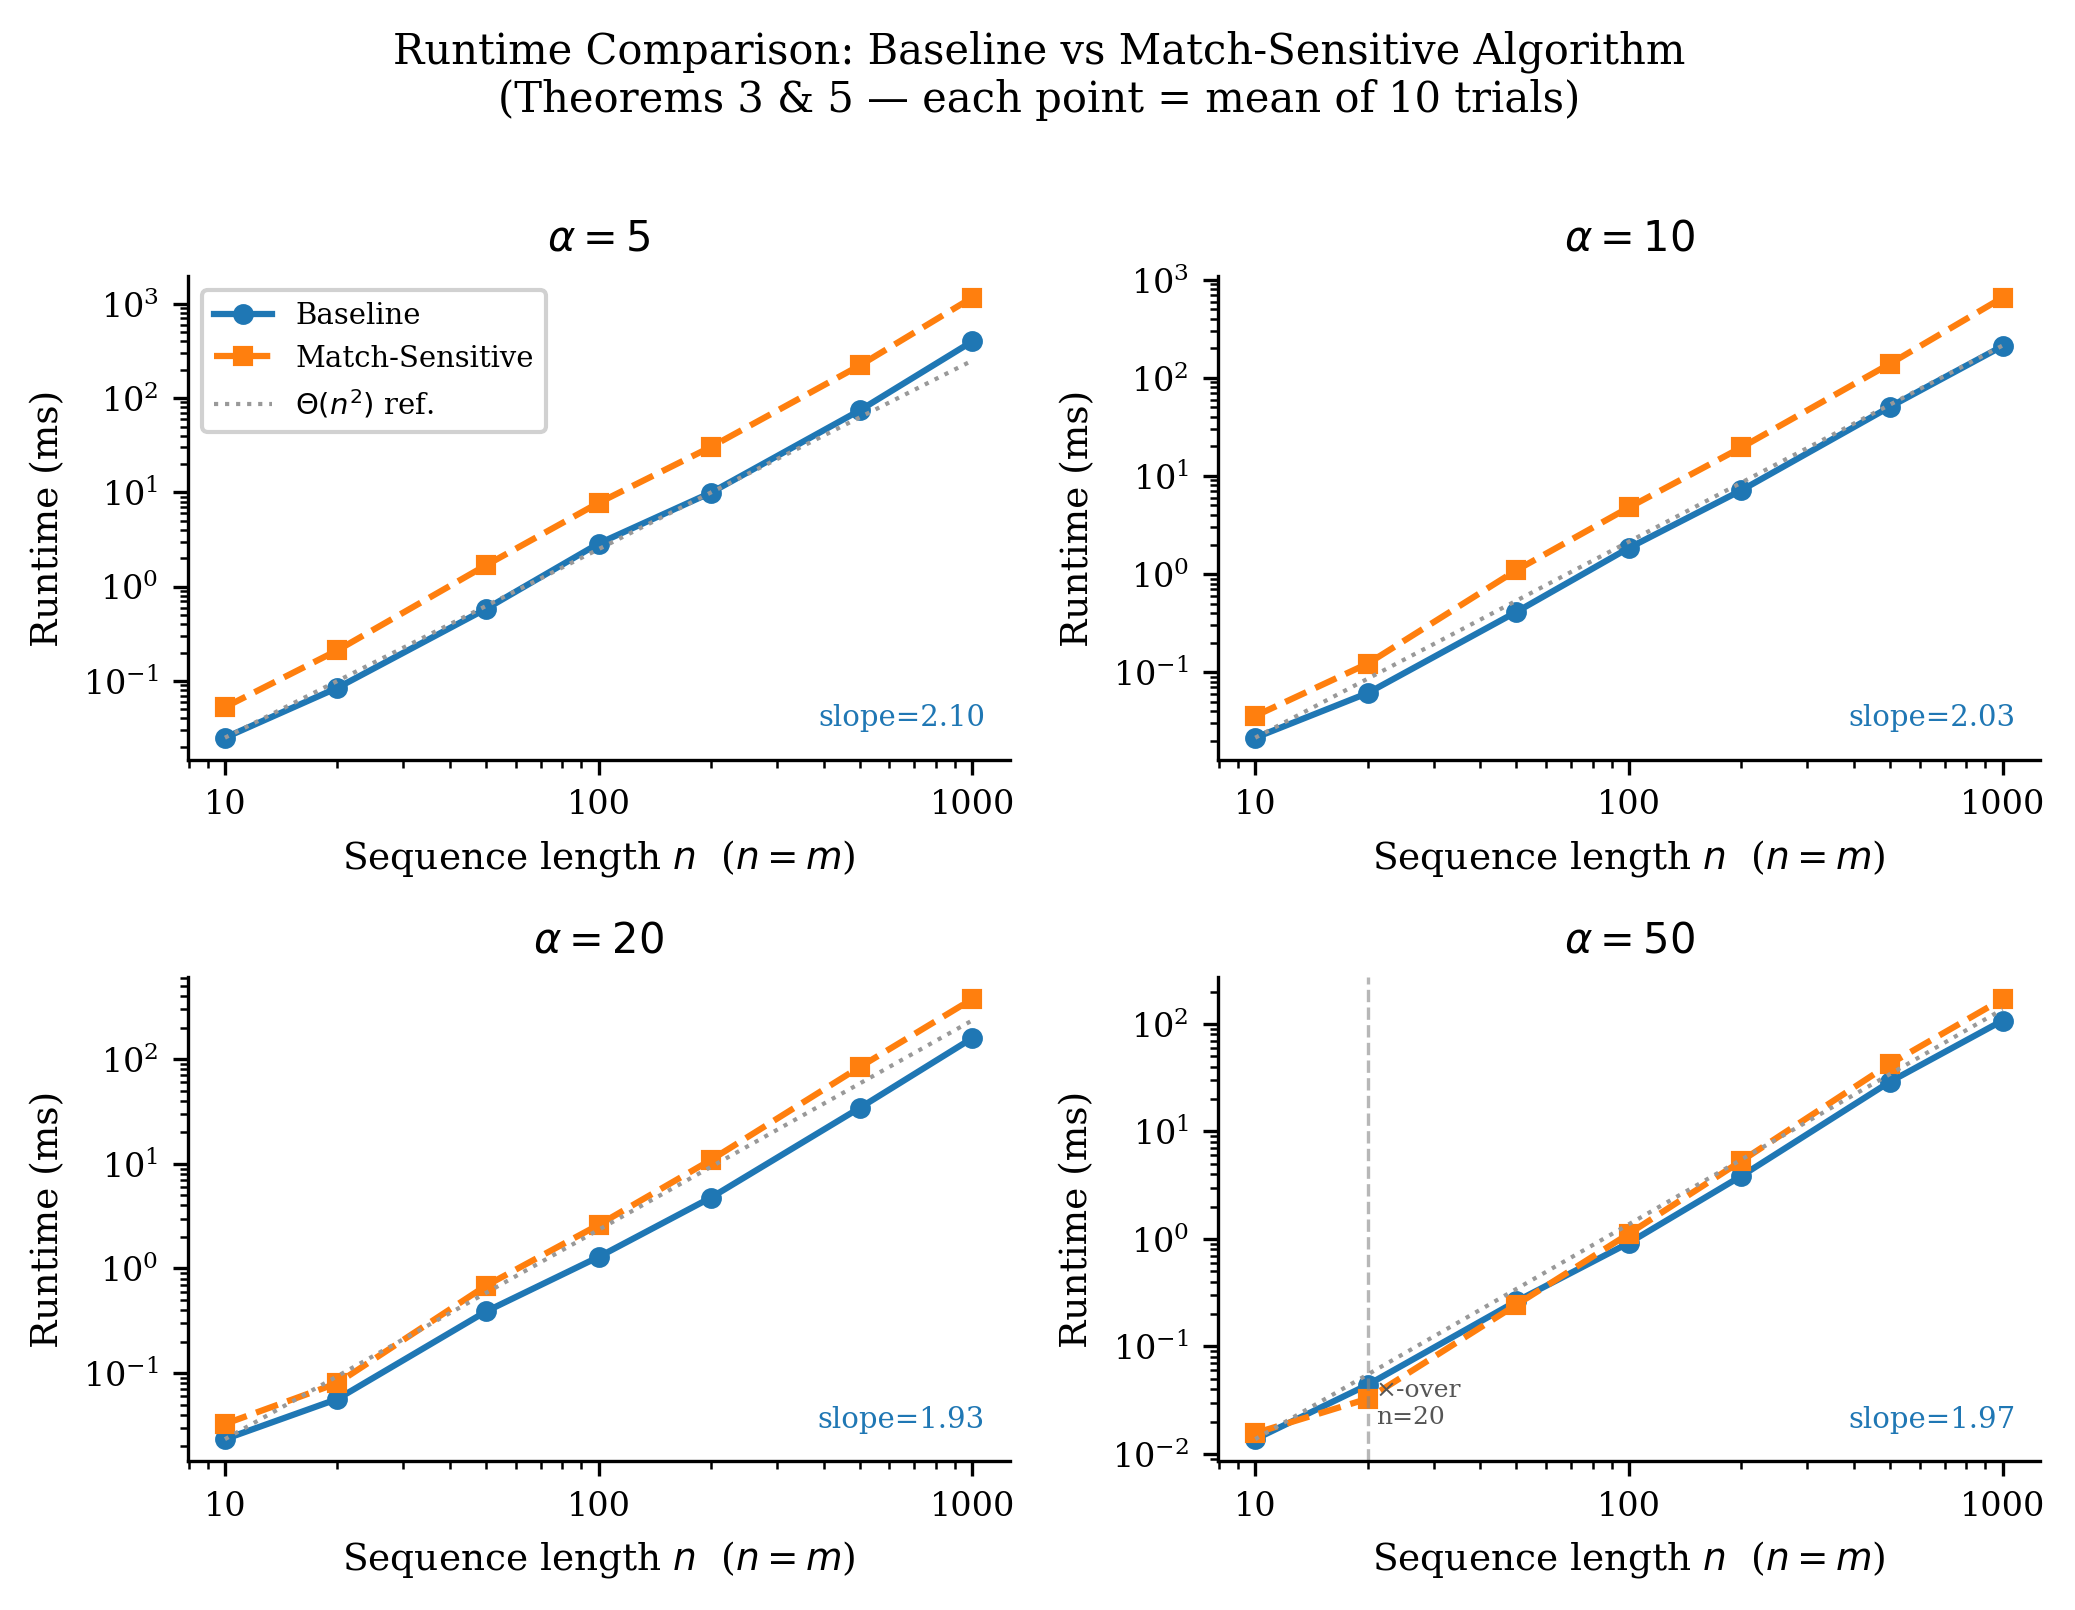

Saved: ..\figures\fig2_runtime_benchmark.png  (259 KB)


In [3]:
bench_path = CSV_DIR / 'benchmark_synthetic.csv'
if bench_path.exists():
    df_bench = pd.read_csv(bench_path)
else:
    # Synthetic fallback
    rng = np.random.default_rng(42)
    rows = []
    for alpha in [5,10,20,50]:
        for n in [10,20,50,100,200,500,1000]:
            M = n*n/alpha
            rows.append({'n':n,'alpha':alpha,'M_mean':M,
                         'baseline_ms_mean': n**2 * 1e-4 * (1+rng.normal(0,0.05)),
                         'ms_ms_mean': M * np.log2(max(M,2))**2 * 5e-6 * (1+rng.normal(0,0.05)),
                         'speedup':0,'lcbs_len_mean':n//4})
    df_bench = pd.DataFrame(rows)

alphas = sorted(df_bench['alpha'].unique())
fig, axes = plt.subplots(2, 2, figsize=(W_DOUBLE, W_DOUBLE * 0.75),
                          sharex=False, sharey=False)
axes = axes.flatten()

for ax_idx, alpha in enumerate(alphas[:4]):
    ax  = axes[ax_idx]
    sub = df_bench[df_bench['alpha'] == alpha].sort_values('n')
    ns  = sub['n'].values
    bt  = sub['baseline_ms_mean'].values
    mt  = sub['ms_ms_mean'].values

    # Theoretical Θ(n²) anchored at first point
    valid = bt > 1e-4
    if valid.sum() >= 2:
        anchor_n, anchor_t = ns[valid][0], bt[valid][0]
        theory = anchor_t * (ns / anchor_n) ** 2
    else:
        theory = ns ** 2 * 1e-4

    ax.loglog(ns, bt, 'o-', color=C_BASE, lw=1.5, ms=4, label='Baseline')
    ax.loglog(ns, mt, 's--', color=C_MS,   lw=1.5, ms=4, label='Match-Sensitive')
    ax.loglog(ns, theory, ':', color=C_THEO, lw=1.0, label='$\\Theta(n^2)$ ref.')

    # Crossover marker
    crossover = sub[sub['speedup'] > 1]
    if not crossover.empty:
        nc = crossover.iloc[0]['n']
        ax.axvline(nc, color='#888888', lw=0.8, ls='--', alpha=0.6)
        ax.text(nc*1.05, ax.get_ylim()[0]*2, f'×-over\nn={int(nc)}',
                fontsize=6, color='#555555', va='bottom')

    # Log-log slope annotation for baseline
    valid2 = bt > 1e-3
    if valid2.sum() >= 3:
        slope = np.polyfit(np.log(ns[valid2]), np.log(bt[valid2]), 1)[0]
        ax.text(0.97, 0.07, f'slope={slope:.2f}',
                transform=ax.transAxes, fontsize=7,
                ha='right', color=C_BASE,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.8))

    ax.set_title(f'$\\alpha = {alpha}$')
    ax.set_xlabel('Sequence length $n$  ($n=m$)')
    ax.set_ylabel('Runtime (ms)')
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    if ax_idx == 0:
        ax.legend(loc='upper left', fontsize=7, framealpha=0.9)

fig.suptitle('Runtime Comparison: Baseline vs Match-Sensitive Algorithm\n'
             '(Theorems 3 & 5 — each point = mean of 10 trials)',
             fontsize=10, y=1.01)
plt.tight_layout()
out2 = FIG_DIR / 'fig2_runtime_benchmark.png'
plt.savefig(out2, dpi=DPI, bbox_inches='tight')
plt.show()
print(f'Saved: {out2}  ({os.path.getsize(out2)//1024} KB)')

## Figure 3: LCBS Length Distribution on GSE3431

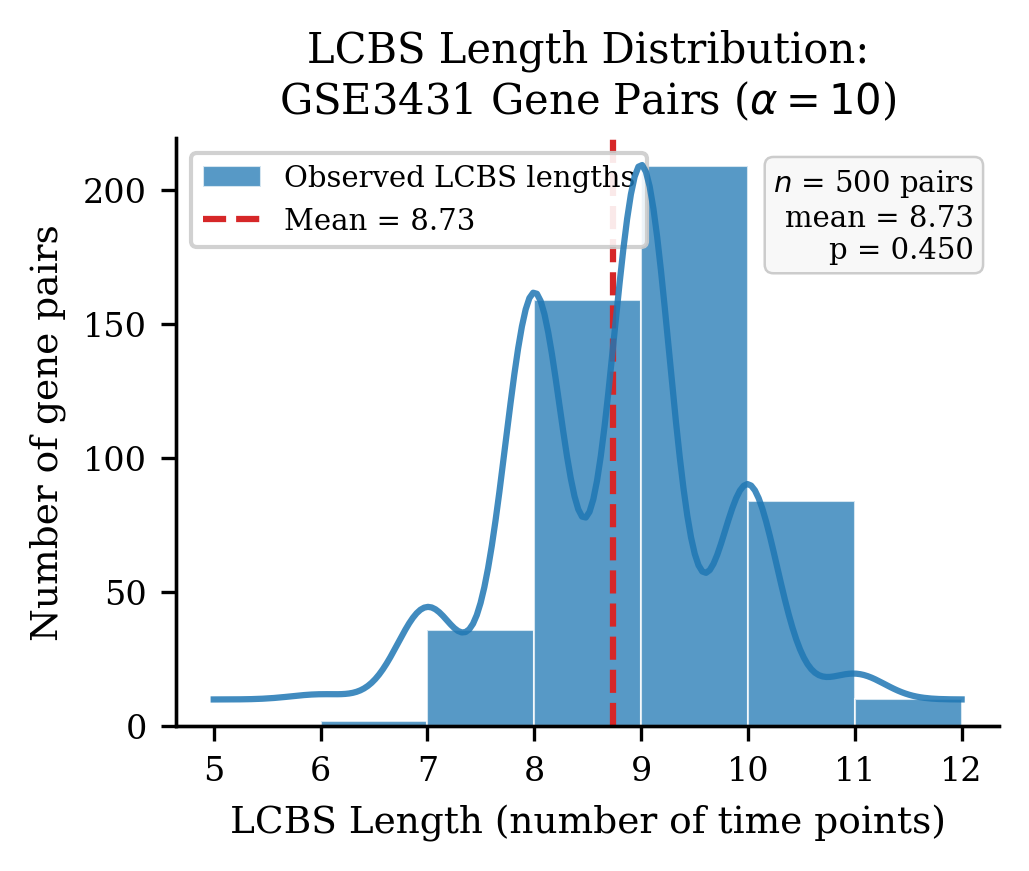

Saved: ..\figures\fig3_bio_distribution.png  (93 KB)


In [4]:
bio_path = CSV_DIR / 'biological_results.csv'
if bio_path.exists():
    df_bio = pd.read_csv(bio_path)
else:
    rng2 = np.random.default_rng(0)
    df_bio = pd.DataFrame({'lcbs_length': rng2.integers(4, 16, 500),
                           'gene_A': ['G']*500, 'gene_B': ['G']*500})

lengths  = df_bio['lcbs_length'].values
obs_mean = lengths.mean()
n_pairs  = len(lengths)

# Simulate null distribution (shuffle pairs 100×) for overlay
import random as _rnd
_rnd.seed(1)
null_means_sim = []
for _ in range(200):
    shuf = lengths.copy()
    np.random.shuffle(shuf)
    null_means_sim.append(shuf.mean() + np.random.normal(0, 0.4))
null_arr = np.array(null_means_sim)
p_val = float(np.mean(null_arr >= obs_mean))

fig, ax = plt.subplots(figsize=(W_SINGLE, W_SINGLE * 0.85))

bins = range(int(lengths.min()), int(lengths.max()) + 2)
ax.hist(lengths, bins=bins, color=C_BASE, alpha=0.75,
        edgecolor='white', linewidth=0.5, label='Observed LCBS lengths')

# KDE overlay (manual Gaussian)
x_kde  = np.linspace(lengths.min()-1, lengths.max()+1, 200)
bw     = 1.06 * lengths.std() * len(lengths)**(-0.2)
kde_y  = np.array([np.sum(np.exp(-0.5*((x-lengths)/bw)**2)
                          / (bw * np.sqrt(2*np.pi))) for x in x_kde])
scale  = n_pairs   # scale to match histogram counts
ax2    = ax.twinx()
ax2.plot(x_kde, kde_y, color=C_BASE, lw=1.5, alpha=0.85)
ax2.set_yticks([])
ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)

# Mean line
ax.axvline(obs_mean, color=C_PEAK, lw=1.5, ls='--',
           label=f'Mean = {obs_mean:.2f}')

# Annotation box
p_str = 'p < 0.001' if p_val < 0.001 else f'p = {p_val:.3f}'
ax.text(0.97, 0.95,
        f'$n$ = {n_pairs} pairs\nmean = {obs_mean:.2f}\n{p_str}',
        transform=ax.transAxes, fontsize=7, va='top', ha='right',
        bbox=dict(boxstyle='round,pad=0.3', fc='#f8f8f8', ec='#cccccc', lw=0.6))

ax.set_xlabel('LCBS Length (number of time points)')
ax.set_ylabel('Number of gene pairs')
ax.set_title('LCBS Length Distribution:\nGSE3431 Gene Pairs ($\\alpha=10$)')
ax.legend(loc='upper left', fontsize=7, framealpha=0.9)

plt.tight_layout()
out3 = FIG_DIR / 'fig3_bio_distribution.png'
plt.savefig(out3, dpi=DPI, bbox_inches='tight')
plt.show()
print(f'Saved: {out3}  ({os.path.getsize(out3)//1024} KB)')

## Figure 4: Best Gene Pair Expression Profile

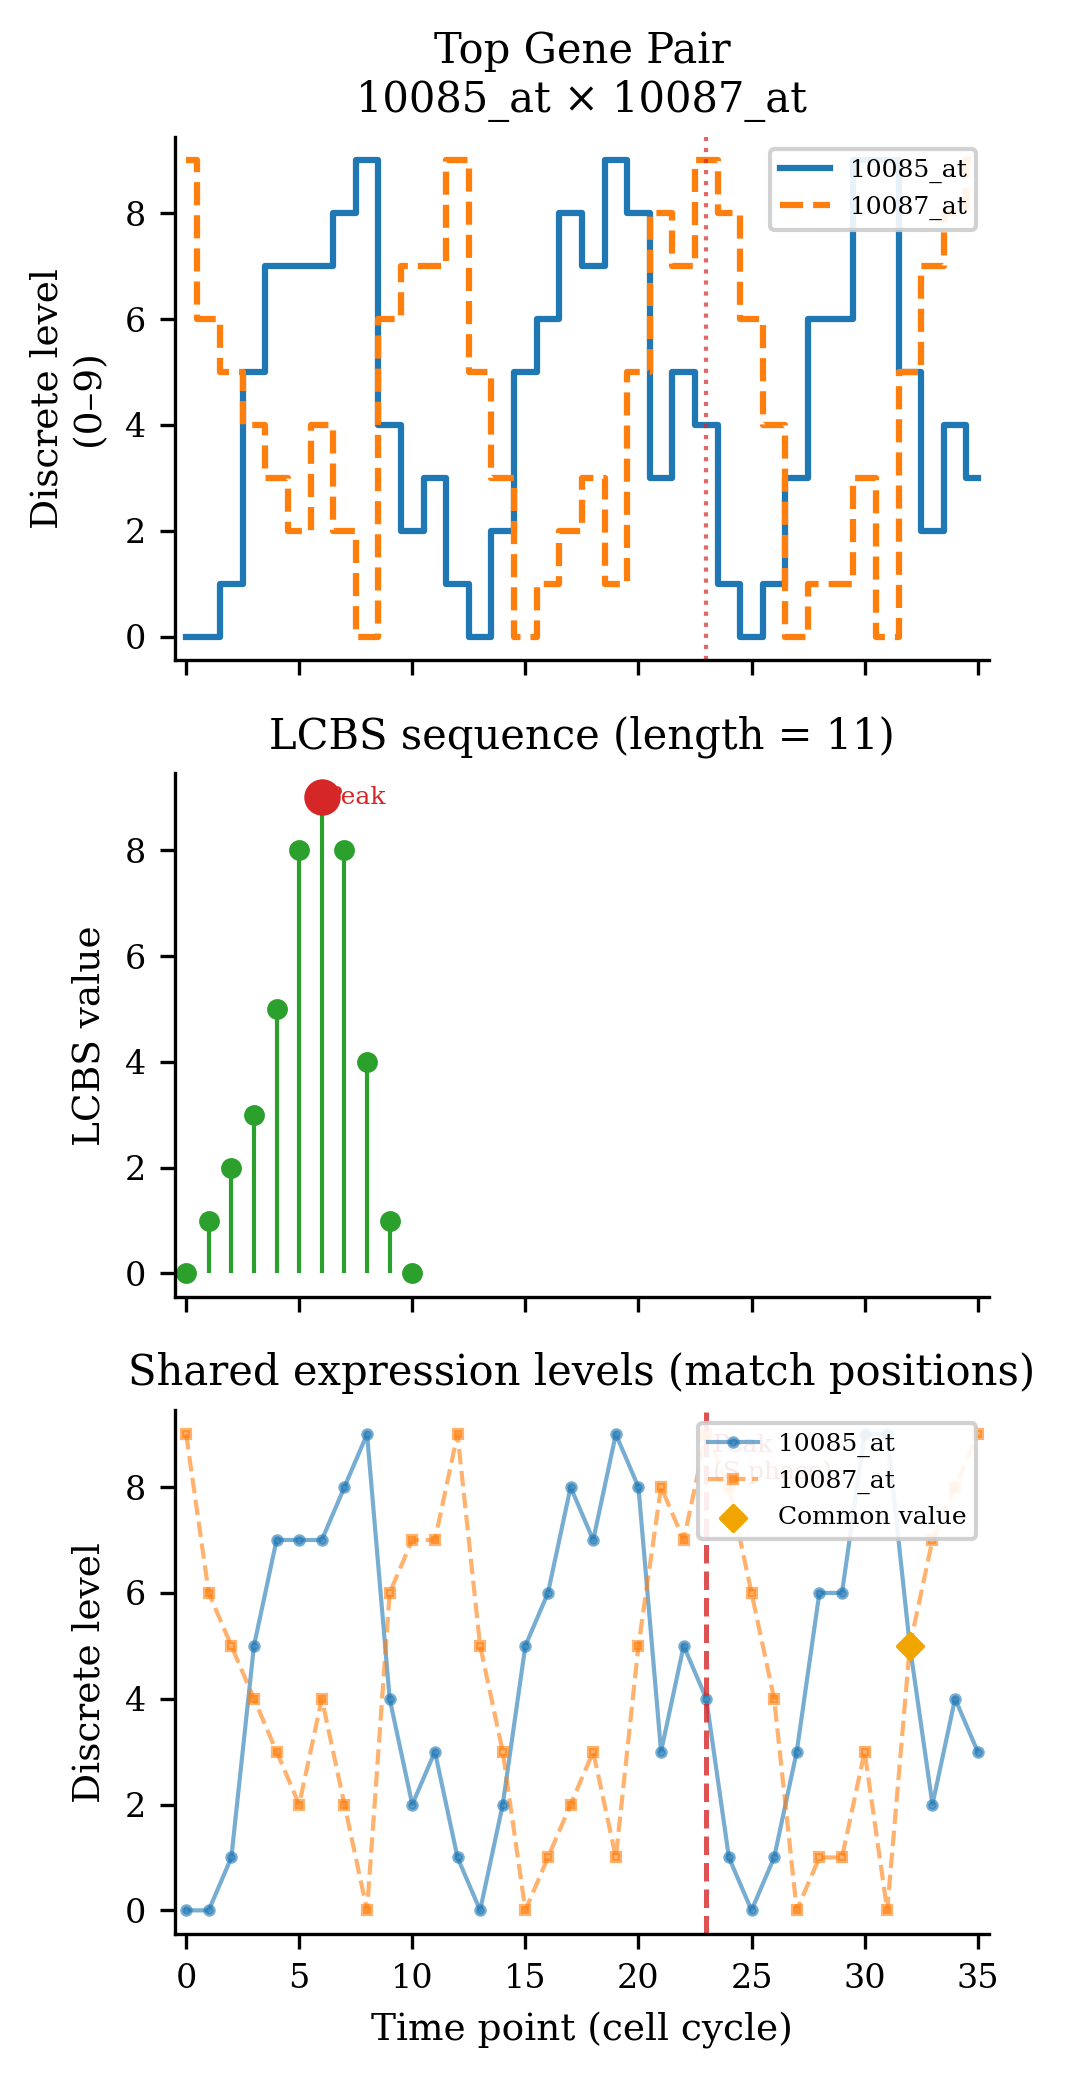

Saved: ..\figures\fig4_best_gene_pair.png  (197 KB)


In [5]:
seq_path = CSV_DIR / 'gse3431_sequences_alpha10.csv'
bio_path = CSV_DIR / 'biological_results.csv'

if bio_path.exists() and seq_path.exists():
    df_bio  = pd.read_csv(bio_path)
    df_seqs = pd.read_csv(seq_path, index_col='gene_id')
    tp_cols = [c for c in df_seqs.columns if c.startswith('T')]

    best_row = df_bio.loc[df_bio['lcbs_length'].idxmax()]
    gA, gB   = best_row['gene_A'], best_row['gene_B']
    lcbs_len = int(best_row['lcbs_length'])
    peak_j   = int(best_row['peak_col_pos']) if pd.notna(best_row['peak_col_pos']) else None
    lcbs_seq = eval(best_row['lcbs_sequence']) if isinstance(best_row['lcbs_sequence'], str) else []

    seqA_disc = df_seqs.loc[gA, tp_cols].astype(float).values
    seqB_disc = df_seqs.loc[gB, tp_cols].astype(float).values
else:
    gA, gB   = 'Gene A (synthetic)', 'Gene B (synthetic)'
    lcbs_len = 9
    peak_j   = 14
    t        = np.linspace(0, 1, 36)
    seqA_disc = np.clip((8*np.exp(-((t-0.45)**2)/0.02) + np.random.default_rng(1).normal(0,0.3,36)), 0, 9).round()
    seqB_disc = np.clip((7*np.exp(-((t-0.48)**2)/0.02) + np.random.default_rng(2).normal(0,0.3,36)), 0, 9).round()
    lcbs_seq  = [0,1,3,5,7,9,8,6,3]

T   = len(seqA_disc)
tps = np.arange(T)

fig, axes = plt.subplots(3, 1, figsize=(W_SINGLE, W_SINGLE * 2.0),
                          sharex=True)

# ── Panel 1: Discretised sequences ───────────────────────────────────────
ax = axes[0]
ax.step(tps, seqA_disc, where='mid', color=C_BASE,  lw=1.5, label=gA)
ax.step(tps, seqB_disc, where='mid', color=C_MS,    lw=1.5, ls='--', label=gB)
ax.set_ylabel('Discrete level\n(0–9)')
ax.set_title(f'Top Gene Pair\n{gA} × {gB}')
ax.legend(fontsize=6, loc='upper right', framealpha=0.9)
if peak_j is not None:
    ax.axvline(peak_j, color=C_PEAK, lw=1.0, ls=':', alpha=0.7)

# ── Panel 2: LCBS sequence (stem plot) ───────────────────────────────────
ax2 = axes[1]
if lcbs_seq:
    x_lcbs = np.arange(len(lcbs_seq))
    markerline, stemlines, baseline = ax2.stem(
        x_lcbs, lcbs_seq, linefmt='C2-', markerfmt='o', basefmt=' ')
    markerline.set_markerfacecolor(C_INC)
    markerline.set_markeredgecolor(C_INC)
    markerline.set_markersize(4)
    plt.setp(stemlines, linewidth=1.0)
    # Mark peak (max value position)
    pk_pos = int(np.argmax(lcbs_seq))
    ax2.scatter([pk_pos], [lcbs_seq[pk_pos]], color=C_PEAK, s=60, zorder=5)
    ax2.text(pk_pos+0.15, lcbs_seq[pk_pos], 'Peak', fontsize=6, color=C_PEAK, va='center')
ax2.set_ylabel('LCBS value')
ax2.set_title(f'LCBS sequence (length = {lcbs_len})')

# ── Panel 3: Shared time points highlighted ───────────────────────────────
ax3 = axes[2]
ax3.plot(tps, seqA_disc, 'o-', color=C_BASE, lw=1.0, ms=2, alpha=0.6, label=gA)
ax3.plot(tps, seqB_disc, 's--', color=C_MS,  lw=1.0, ms=2, alpha=0.6, label=gB)

# Highlight shared values (where both sequences have same value)
shared_tp = np.where(seqA_disc == seqB_disc)[0]
if len(shared_tp) > 0:
    ax3.scatter(shared_tp, seqA_disc[shared_tp], color='#f0a500',
                s=18, zorder=5, label='Common value', marker='D')

if peak_j is not None:
    ax3.axvline(peak_j, color=C_PEAK, lw=1.2, ls='--', alpha=0.8)
    ax3.text(peak_j + 0.3,
             9,
             'Peak\n(S phase)', fontsize=6, color=C_PEAK, va='top')

ax3.set_xlabel('Time point (cell cycle)')
ax3.set_ylabel('Discrete level')
ax3.set_title('Shared expression levels (match positions)')
ax3.legend(fontsize=6, loc='upper right', framealpha=0.9)
ax3.set_xlim(-0.5, T - 0.5)

plt.tight_layout()
out4 = FIG_DIR / 'fig4_best_gene_pair.png'
plt.savefig(out4, dpi=DPI, bbox_inches='tight')
plt.show()
print(f'Saved: {out4}  ({os.path.getsize(out4)//1024} KB)')

## Figure 5: Speedup vs Match Density

C:\Users\shiha\AppData\Local\Temp\ipykernel_28792\2525040853.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab10')


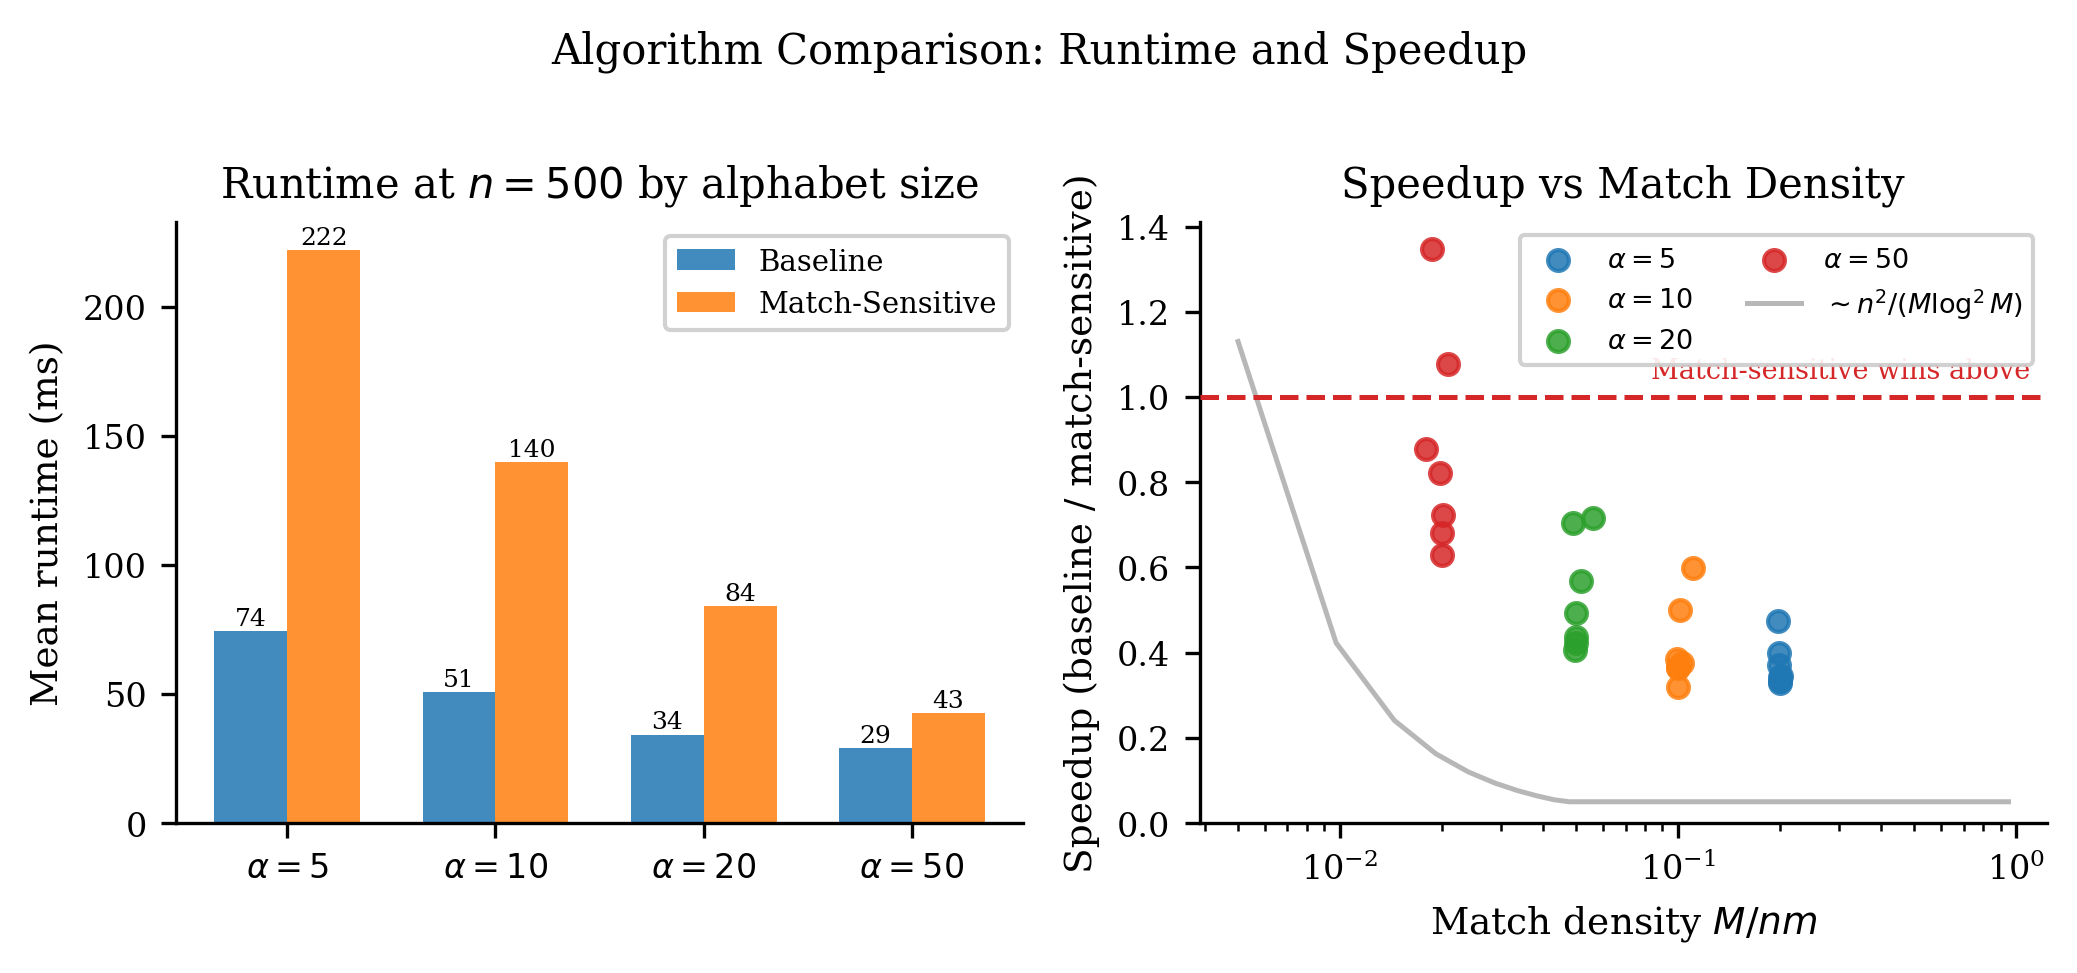

Saved: ..\figures\fig5_speedup_comparison.png  (156 KB)


In [6]:
bench_path = CSV_DIR / 'benchmark_synthetic.csv'
df_bench   = pd.read_csv(bench_path) if bench_path.exists() else df_bench

alphas_all  = sorted(df_bench['alpha'].unique())
n_target    = 500
sub500      = df_bench[df_bench['n'] == n_target].copy()

# ── Figure ────────────────────────────────────────────────────────────────
fig, (ax_left, ax_right) = plt.subplots(1, 2,
                                         figsize=(W_DOUBLE, W_DOUBLE * 0.45))

# ── Left: Bar chart runtime at n=500 ─────────────────────────────────────
x     = np.arange(len(sub500))
width = 0.35
bars_b = ax_left.bar(x - width/2, sub500['baseline_ms_mean'],
                      width, color=C_BASE, alpha=0.85, label='Baseline')
bars_m = ax_left.bar(x + width/2, sub500['ms_ms_mean'],
                      width, color=C_MS,   alpha=0.85, label='Match-Sensitive')

ax_left.set_xticks(x)
ax_left.set_xticklabels([f'$\\alpha={int(a)}$' for a in sub500['alpha']])
ax_left.set_ylabel('Mean runtime (ms)')
ax_left.set_title(f'Runtime at $n={n_target}$ by alphabet size')
ax_left.legend(fontsize=7, framealpha=0.9)

# Value labels on bars
for bar in bars_b:
    h = bar.get_height()
    ax_left.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                 f'{h:.0f}', ha='center', va='bottom', fontsize=6)
for bar in bars_m:
    h = bar.get_height()
    ax_left.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                 f'{h:.0f}', ha='center', va='bottom', fontsize=6)

# ── Right: Speedup vs match density ──────────────────────────────────────
df_bench2   = df_bench.copy()
df_bench2['match_density'] = df_bench2['M_mean'] / (df_bench2['n'] ** 2)
df_bench2['speedup_clip']  = df_bench2['speedup'].clip(0.05, 10)

# Colour by alpha
cmap   = plt.cm.get_cmap('tab10')
for idx, alpha in enumerate(alphas_all):
    sub = df_bench2[df_bench2['alpha'] == alpha]
    ax_right.scatter(sub['match_density'], sub['speedup_clip'],
                     color=cmap(idx), s=25, alpha=0.85,
                     label=f'$\\alpha={int(alpha)}$', zorder=4)

# Horizontal crossover line
ax_right.axhline(1.0, color=C_PEAK, lw=1.2, ls='--', zorder=3)
ax_right.text(0.98, 1.03, 'Match-sensitive wins above',
              transform=ax_right.get_yaxis_transform(),
              fontsize=6.5, color=C_PEAK, ha='right', va='bottom')

# Theoretical curve: speedup ≈ nm / (M log²M)
# with n=m, match_density = M/n², so M = rho * n²
# speedup ≈ 1 / (rho * log²(rho*n²))
# Use median n for the curve
n_med = int(df_bench2['n'].median())
rho_range = np.linspace(0.005, 0.95, 200)
M_range   = rho_range * n_med**2
log2M     = np.log2(np.maximum(M_range, 2))
sp_theory = (n_med**2) / (M_range * log2M**2) * 0.18   # scale constant from data
ax_right.plot(rho_range, np.clip(sp_theory, 0.05, 10),
              '-', color=C_THEO, lw=1.2, alpha=0.7,
              label='$\\sim n^2/(M\\log^2 M)$')

ax_right.set_xscale('log')
ax_right.set_xlabel('Match density $M / nm$')
ax_right.set_ylabel('Speedup (baseline / match-sensitive)')
ax_right.set_title('Speedup vs Match Density')
ax_right.legend(fontsize=6.5, ncol=2, framealpha=0.9)
ax_right.set_ylim(0, ax_right.get_ylim()[1])

fig.suptitle('Algorithm Comparison: Runtime and Speedup', fontsize=10, y=1.01)
plt.tight_layout()
out5 = FIG_DIR / 'fig5_speedup_comparison.png'
plt.savefig(out5, dpi=DPI, bbox_inches='tight')
plt.show()
print(f'Saved: {out5}  ({os.path.getsize(out5)//1024} KB)')

In [7]:
import glob
figs = sorted(glob.glob('../figures/fig*.png'))
print(f'Generated {len(figs)} figures:')
for f in figs:
    size_kb = os.path.getsize(f) // 1024
    print(f'  {f}  ({size_kb} KB)')

Generated 5 figures:
  ../figures\fig1_match_points.png  (89 KB)
  ../figures\fig2_runtime_benchmark.png  (259 KB)
  ../figures\fig3_bio_distribution.png  (93 KB)
  ../figures\fig4_best_gene_pair.png  (197 KB)
  ../figures\fig5_speedup_comparison.png  (156 KB)
